# Chinese polities vs Cross-Verified
Pairs Cultura Chinese polities with Cross-Verified citizenship tokens and compares their counts.

## Configuration

In [1]:
import tempfile
from collections import defaultdict
import duckdb
import polars as pl
import matplotlib.pyplot as plt
from style import *

DB_PATH = '../data/cultura/humans_clean_enriched_v3.duckdb'
CROSS_VERIFIED_DB_PATH = '../data/similar_databases/cross_verified.duckdb'

PANEL_BREAKS = [220, 618, 1368]

apply_style()

## External data — Cross-Verified, hand-curated pairing

In [2]:
cv_con = duckdb.connect(CROSS_VERIFIED_DB_PATH, read_only=True)
cv_raw_citizenship = cv_con.sql("""
    SELECT wikidata_code, string_citizenship_raw_d
    FROM   individuals
    WHERE  string_citizenship_raw_d IS NOT NULL
      AND  string_citizenship_raw_d != ''
      AND  wikidata_code IS NOT NULL
""").pl()
cv_con.close()

TOKEN_JOINER = "'_'"

def tokenize_cv_citizenship(raw):
    raw = raw.strip()
    if raw.startswith("'") and raw.endswith("'"):
        raw = raw[1:-1]
    return [token for token in raw.split(TOKEN_JOINER) if token]

token_to_qids = defaultdict(set)
for qid, raw in cv_raw_citizenship.iter_rows():
    for token in tokenize_cv_citizenship(raw):
        token_to_qids[token].add(qid)

print(f'CV rows with a citizenship string: {cv_raw_citizenship.height:,}')
print(f'distinct CV tokens: {len(token_to_qids):,}')
cv_raw_citizenship.head()

CV rows with a citizenship string: 1,845,231
distinct CV tokens: 1,784


wikidata_code,string_citizenship_raw_d
str,str
"""Q1000002""","""'Germany'"""
"""Q1000005""","""'Czech_Republic'"""
"""Q1000006""","""'Germany'"""
"""Q1000015""","""'Germany'"""
"""Q1000023""","""'Germany'"""


### Polity–token pairing

In [3]:
CHINESE_PAIRS = [
    (None,                                              [('Xia_dynasty',                    None)]),
    ('Shang Dynasty',                                   [('Shang_dynasty',                  '-1599 to -1045')]),
    ('Zhou Dynasty',                                    [('Western_Zhou',                   '-1045 to -770'),
                                                          ('Zhou_dynasty',                   '-1045 to -255')]),
    ('Spring and Autumn States',                        []),
    ('Chu',                                             [('Chu',                            '-208 to -207')]),
    ('Qi',                                              []),
    ('Zheng',                                           []),
    ('Teng',                                            []),
    ('Wu',                                              [('Wu',                             '-280')]),
    ('Qin',                                             []),
    ('Later Zhou',                                      [('Later_Zhou_dynasty',             '951-960')]),
    ('Yue',                                             []),
    ('Warring States China',                            []),
    ('Zhao',                                            [('Zhao',                           '910-')]),
    ('Wei',                                             [('Wei',                            '-402 to -224')]),
    ('Han',                                             [('Han',                            '-220')]),
    ('Zhongshan',                                       []),
    ('Minyue',                                          []),
    ('Xiongnu',                                         [('Xiongnu',                        '-300 to 500')]),
    ('Qin Dynasty',                                     [('Qin_Dynasty',                    '-220 to -205')]),
    ('Zhai',                                            []),
    ('Nanyue',                                          [('Nanyue',                         '-203 to -110')]),
    ('Han Dynasty',                                     [('Han_Dynasty',                    '-205 to 220'),
                                                          ('Western_Han_Dynasty',            None),
                                                          ('Eastern_Han_Dynasty',            None)]),
    ('Great Yuan',                                      []),
    ('Goguryeo',                                        [('Goguryeo',                       '-36 to 668')]),
    ('Xin Dynasty',                                     [('Xin_dynasty',                    '9-23')]),
    ('Southern Xiongnu',                                []),
    ('Eastern Wu',                                      [('Eastern_Wu',                     '198-280')]),
    ('Cao Wei',                                         [('Cao_Wei',                        '220-265')]),
    ('Shu Han',                                         [('Shu_Han',                        '221-263')]),
    ('Yan Kingdom',                                     [('Yan',                            '237-238')]),
    ('Western Jin',                                     [('Western_Jin_dynasty',            '265-316'),
                                                          ('Jin_dynasty',                    '266-420'),
                                                          ('Jin_Dynasty',                    '266-420')]),
    ('Tuyuhun',                                         []),
    ('Former Zhao',                                     [('Han_Zhao',                       '304-329')]),
    ('Cheng Han',                                       [('Cheng_Han',                      '304-347')]),
    ('Eastern Jin',                                     [('Eastern_Jin_dynasty',            '317-420'),
                                                          ('Former_Liang',                   '320-376')]),
    ('Later Zhao',                                      []),
    ('Former Qin',                                      [('Former_Qin',                     '350-394')]),
    ('Later Qin',                                       [('Later_Qin',                      '384-417'),
                                                          ('Later_Yan',                      '384-409')]),
    ('Northern Wei',                                    [('Northern_Wei',                   '386-535')]),
    ('Western Qin',                                     []),
    ('Northern Liang',                                  []),
    ('Southern Liang',                                  [('Southern_Yan',                   '398-410')]),
    ('Western Liang',                                   [('Western_Liang',                  '400-421')]),
    ('Alliance between Northern Wei and Rouran Khaganate', []),
    ('Xia',                                             []),
    ('Liu Song Dynasty',                                [('Liu_Song_dynasty',               '420-479'),
                                                          ('Southern_Qi',                    '479-502')]),
    ('Liang Dynasty',                                   [('Liang_dynasty',                  '502-587')]),
    ('Eastern Wei',                                     [('Eastern_Wei',                    '534-550')]),
    ('Western Wei',                                     []),
    ('Northern Qi',                                     [('Northern_Qi',                    '550-577')]),
    ('Chen Dynasty',                                    [('Chen_dynasty',                   '557-589')]),
    ('Northern Zhou',                                   [('Northern_Zhou',                  '557-581')]),
    ('Sui Dynasty',                                     [('Sui_Dynasty',                    '581-618')]),
    ('Tang Dynasty',                                    [('Tang_dynasty',                   '618-907'),
                                                          ('Zhou_dynasty_(690–705)',         '690-705')]),
    ('Tibetan Empire',                                  [('Tibetan_Empire',                 '618-842')]),
    ('Balhae',                                          [('Balhae',                         '698-926')]),
    ('Nanzhao',                                         []),
    ('Tibetans',                                        []),
    ('Kara-Khanids',                                    [('Kara-Khanid_Khanate',            None)]),
    ('Qocho Kingdom',                                   []),
    ('Ganzhou Kingdom',                                 []),
    ('Kingdom of Khotan',                               []),
    ('Former Shu',                                      [('Former_Shu',                     '907-925')]),
    ('Later Liang Dynasty',                             [('Later_Liang_dynasty',            '907-923')]),
    ('Wuyue',                                           [('Wuyue',                          '907-978')]),
    ('Qi Kingdom',                                      []),
    ('Five Dynasties and Ten Kingdoms',                 []),
    ('Later Jin',                                       [('Later_Jin',                      None)]),
    ('Southern Han',                                    [('Southern_Han',                   '917-971')]),
    ('Southern Chu',                                    []),
    ('Liao Dynasty',                                    [('Liao_dynasty',                   '916-1125')]),
    ('Jingnan',                                         [('Jingnan',                        '924-963')]),
    ('Later Tang',                                      [('Later_Tang_Dynasty',             None)]),
    ('Later Shu',                                       []),
    ('Later Jin Dynasty',                               [('Later_Jin_Dynasty',              '936-947')]),
    ('Southern Tang',                                   [('Southern_Tang',                  '937-976')]),
    ('Later Han',                                       [('Later_Han_dynasty',              '947-951')]),
    ('Kingdom of Dali',                                 []),
    ('Northern Han',                                    []),
    ('Northern Song',                                   [('Northern_Song_Dynasty',          '960-1127'),
                                                          ('Song_Dynasty',                   '960-1279')]),
    ('Western Xia',                                     [('Western_Xia',                    '1038-1227')]),
    ('Southern Song',                                   [('Southern_Song_Dynasty',          '1127-1279')]),
    ('Eastern Kara-Khanids',                            []),
    ('Western Karakhanid Khanate',                      []),
    ('Mongol Empire',                                   [('Mongol_Empire',                  '1206-1368'),
                                                          ('Khamag_Mongol',                  '1120-1206')]),
    ('Vassalage of Western Xia to Great Jin',           []),
    ('Chagatai Khanate',                                [('Chagatai_Khanate',               '1225-1687')]),
    ('Yuan Dynasty',                                    [('Yuan_dynasty',                   '1271-1368')]),
    ('Allegiance of Chagatai Khanate to Yuan Dynasty',  []),
    ('Allegiance of Golden Horde to Yuan Dynasty',      []),
    ('Allegiance of Ilkhanate to Yuan Dynasty',         []),
    ('Moghulistan',                                     [('Moghulistan',                    '1347-1570')]),
    ('Tibet',                                           [('Tibet',                          None)]),
    ('Northern Yuan',                                   [('Northern_Yuan_Dynasty',          '1368-1691')]),
    ('Ming Dynasty',                                    [('Ming_dynasty',                   '1368-1644')]),
    ('East Turkestan',                                  [('First_East_Turkestan_Republic',  '1933-1934')]),
    ('Eastern Chagatai Khanate',                        []),
    ('Eastern Moghulistan',                             []),
    ('Western Moghulistan',                             []),
    (None,                                              [('Macau',                          '1557-')]),
    ('Khoshut Khanate',                                 [('Khoshut_Khanate',                '1650-1724')]),
    ('Dzungar Khanate',                                 [('Zunghar_Khanate',                None)]),
    ('Qing Dynasty',                                    [('Qing_dynasty',                   '1636-1912')]),
    ('Southern Ming',                                   [('Southern_Ming_Dynasty',          '1644-1661'),
                                                          ('Shun_Dynasty',                   '1644-1644')]),
    (None,                                              [('British_Hong_Kong',              '1841-1997')]),
    ('Taiping Heavenly Kingdom',                        [('Taiping_Heavenly_Kingdom',       '1851-1864')]),
    ('French Indochina',                                [('French_Indochina',               '1887-1954')]),
    ('Republic of China',                               [('Republic_of_China',              None),
                                                          ('Taiwan',                         '1912-'),
                                                          ('Taiwan_under_Japanese_rule',     '1895-1945'),
                                                          ('Beiyang_Government',             '1913-1928')]),
    ('Great Mongol State',                              []),
    ('Empire of China',                                 [('Empire_of_China',                '1915-1916')]),
    ('Kuomintang',                                      []),
    ('Chinese Communists',                              []),
    ('Anti-Kuomintang Coalition',                       []),
    (None,                                              [('Manchukuo',                      '1932-1945')]),
    ('Communist Party of China',                        []),
    ('East Turkestan Republic',                         [('Second_East_Turkestan_Republic', '1944-1946'),
                                                          ('Inner_Mongolia',                 '1947-')]),
    ("People's Republic of China",                      [("People's_Republic_of_China",     '1949-'),
                                                          ('China',                          None),
                                                          ('Tibet_Autonomous_Region',        '1965-'),
                                                          ('Hong_Kong',                      '1997-'),
                                                          ('Tibet_from_1912_to_1951',        None)]),
]

print(f'pairings        : {len(CHINESE_PAIRS)}')
print(f'paired (both)   : {sum(1 for p, t in CHINESE_PAIRS if p and t)}')
print(f'cliopatria-only : {sum(1 for p, t in CHINESE_PAIRS if p and not t)}')
print(f'cv-only         : {sum(1 for p, t in CHINESE_PAIRS if not p)}')

pairings        : 118
paired (both)   : 70
cliopatria-only : 44
cv-only         : 4


## Load Cultura data

In [4]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")

chinese_polities = pl.DataFrame({'polity_name': [p for p, _ in CHINESE_PAIRS if p]})
con.register('chinese_polities', chinese_polities)

con.sql("""
    CREATE TEMP TABLE individual_polity AS
    SELECT entity.qid                 AS qid,
           unnest(polity).polity.name AS polity_name
    FROM   individual_enriched
""")

cultura_polity_qids = con.sql("""
    SELECT DISTINCT qid, polity_name
    FROM   individual_polity
    WHERE  polity_name IN (SELECT polity_name FROM chinese_polities)
""").pl()

polity_periods = con.sql("""
    SELECT   name                      AS polity_name,
             MIN(territory.start_year) AS from_year,
             MAX(territory.end_year)   AS to_year
    FROM     polity, unnest(territories) AS unnested(territory)
    WHERE    name IN (SELECT polity_name FROM chinese_polities)
    GROUP BY name
""").pl()

missing_polities = set(chinese_polities['polity_name']) - set(polity_periods['polity_name'])
print(f'(individual, Chinese polity) pairs: {cultura_polity_qids.height:,}')
print(f'polities with dates: {polity_periods.height} / {chinese_polities.height}')
print('paired polity names absent from V2 polity table:', sorted(missing_polities))
cultura_polity_qids.head()

(individual, Chinese polity) pairs: 182,805
polities with dates: 113 / 114
paired polity names absent from V2 polity table: ['Eastern Jin']


qid,polity_name
str,str
"""Q109174389""","""People's Republic of China"""
"""Q104782829""","""People's Republic of China"""
"""Q110406594""","""People's Republic of China"""
"""Q7211688""","""People's Republic of China"""
"""Q50771130""","""People's Republic of China"""


## Preprocessing

### Per-polity counts

In [5]:
polity_to_qids = {
    polity: set(qids)
    for polity, qids in cultura_polity_qids.group_by('polity_name').agg(pl.col('qid')).iter_rows()
}
period_lookup = {r['polity_name']: (r['from_year'], r['to_year']) for r in polity_periods.to_dicts()}

polity_counts = (
    pl.DataFrame({'polity_name': list(polity_to_qids), 'n': [len(q) for q in polity_to_qids.values()]})
    .join(polity_periods, on='polity_name', how='left')
    .sort('n', descending=True)
)
assert polity_counts['polity_name'].is_unique().all()
polity_counts.head(10)

polity_name,n,from_year,to_year
str,i64,i64,i64
"""People's Republic of China""",57507,1950,2024
"""Qing Dynasty""",32910,1645,1911
"""Tang Dynasty""",25582,623,910
"""Republic of China""",22869,1912,2024
"""Ming Dynasty""",16640,1375,1644
"""Southern Song""",6348,1028,1278
"""Kuomintang""",3551,1917,1929
"""Yuan Dynasty""",3088,1294,1374
"""Empire of China""",2141,1916,1916


### Paper table panels

In [6]:
def fmt_year(y):
    return f'{-y} BCE' if y < 0 else f'{y}'

def fmt_polity_period(polity):
    pair = period_lookup.get(polity)
    if not pair or pair[0] is None or pair[1] is None:
        return ''
    return f'{fmt_year(pair[0])}–{fmt_year(pair[1])}'

def split_cv_date(s):
    s = s.strip().strip('()').strip()
    if ' to ' in s:
        return s.split(' to ')
    if s.endswith('-'):
        return [s[:-1], '']
    idx = s.find('-', 1)
    return [s] if idx == -1 else [s[:idx], s[idx + 1:]]

def fmt_cv_period(s):
    if not s:
        return ''
    parts = [p.strip() for p in split_cv_date(s)]
    if len(parts) == 1:
        return fmt_year(int(parts[0]))
    a, b = parts
    if not b:
        return fmt_year(int(a)) + '–'
    ai, bi = int(a), int(b)
    if ai < 0 and bi < 0:
        return f'{-ai}–{-bi} BCE'
    if ai < 0:
        return f'{-ai} BCE – {bi} CE'
    return f'{ai}–{bi}'

def sort_key(polity, pairings):
    if polity and period_lookup.get(polity, (None,))[0] is not None:
        return period_lookup[polity][0]
    for _, d in pairings:
        if d:
            return int(split_cv_date(d)[0].strip())
    return None

def fmt_n(n):
    return '' if n is None else f'{n:,}'

flat_rows = []
for polity, pairings in CHINESE_PAIRS:
    head = {
        'cu_polity': polity or '',
        'cu_period': fmt_polity_period(polity) if polity else '',
        'cu_n': fmt_n(len(polity_to_qids.get(polity, set()))) if polity else '',
        'sort_key': sort_key(polity, pairings),
    }
    blank = {'cu_polity': '', 'cu_period': '', 'cu_n': '', 'sort_key': None}
    if not pairings:
        flat_rows.append({**head, 'cv_token': '', 'cv_period': '', 'cv_n': ''})
    for i, (token, cv_date) in enumerate(pairings):
        flat_rows.append({
            **(head if i == 0 else blank),
            'cv_token': token.replace('_', ' '),
            'cv_period': fmt_cv_period(cv_date),
            'cv_n': fmt_n(len(token_to_qids.get(token, set()))),
        })

def split_panels(rows, breakpoints):
    panels = [[] for _ in range(len(breakpoints) + 1)]
    last_key = -10000
    for r in rows:
        if r['sort_key'] is not None:
            last_key = r['sort_key']
        idx = next((i for i, bp in enumerate(breakpoints) if last_key < bp), len(breakpoints))
        panels[idx].append(r)
    return panels

panel_a, panel_b, panel_c, panel_d = split_panels(flat_rows, PANEL_BREAKS)
assert sum(map(len, [panel_a, panel_b, panel_c, panel_d])) == len(flat_rows)
for label, panel in zip('abcd', [panel_a, panel_b, panel_c, panel_d]):
    print(f'panel {label}: {len(panel)} rows')
pl.DataFrame(flat_rows).drop('sort_key').head(10)

panel a: 31 rows
panel b: 30 rows
panel c: 42 rows
panel d: 35 rows


cu_polity,cu_period,cu_n,cv_token,cv_period,cv_n
str,str,str,str,str,str
"""""","""""","""""","""Xia dynasty""","""""","""13"""
"""Shang Dynasty""","""1600 BCE–1001 BCE""","""9""","""Shang dynasty""","""1599–1045 BCE""","""6"""
"""Zhou Dynasty""","""1000 BCE–751 BCE""","""26""","""Western Zhou""","""1045–770 BCE""","""2"""
"""""","""""","""""","""Zhou dynasty""","""1045–255 BCE""","""4"""
"""Spring and Autumn States""","""750 BCE–481 BCE""","""0""","""""","""""",""""""
"""Chu""","""750 BCE–224 BCE""","""136""","""Chu""","""208–207 BCE""","""5"""
"""Qi""","""750 BCE–204 BCE""","""52""","""""","""""",""""""
"""Zheng""","""750 BCE–367 BCE""","""0""","""""","""""",""""""
"""Teng""","""750 BCE–451 BCE""","""1""","""""","""""",""""""


In [7]:
FIELDS = ['cu_polity', 'cu_period', 'cu_n', 'cv_token', 'cv_period', 'cv_n']
HEADERS = ['Cliopatria polity', 'Cliopatria dates', 'Cultura n', 'CV citizenship token', 'CV dates', 'CV n']
COL_X = [0.005, 0.365, 0.575, 0.615, 0.840, 0.995]
COL_ALIGN = ['left', 'left', 'right', 'left', 'left', 'right']

def make_subtotal(rows, label):
    total = lambda f: sum(int(r[f].replace(',', '')) for r in rows if r[f])
    return {'cu_polity': label, 'cu_period': '', 'cu_n': f"{total('cu_n'):,}",
            'cv_token': '', 'cv_period': '', 'cv_n': f"{total('cv_n'):,}"}

def render_pair_table(body_rows, total_row, panel_label):
    fig = plt.figure(figsize=(17, 0.55 * (len(body_rows) + 2) + 0.5), facecolor=BACKGROUND_COLOR)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    top, bottom = 0.93, 0.04
    row_h = (top - bottom) / (len(body_rows) + 2)

    ax.hlines(top, 0, 1, lw=TABLE_RULE_THICK, color=TABLE_RULE_COLOR)
    for h, x, a in zip(HEADERS, COL_X, COL_ALIGN):
        ax.text(x, top - row_h * 0.55, h, ha=a, va='center', fontsize=TABLE_FONT_HEAD, fontweight='bold')
    body_top = top - row_h
    ax.hlines(body_top, 0, 1, lw=TABLE_RULE_THIN, color=TABLE_RULE_COLOR)

    for i, r in enumerate(body_rows + [total_row]):
        y = body_top - row_h * (i + 0.55)
        weight = 'bold' if i == len(body_rows) else 'normal'
        for f, x, a in zip(FIELDS, COL_X, COL_ALIGN):
            ax.text(x, y, r[f], ha=a, va='center', fontsize=TABLE_FONT_BODY, fontweight=weight)

    ax.hlines(body_top - row_h * len(body_rows), 0, 1, lw=TABLE_RULE_THIN, color=TABLE_RULE_COLOR)
    ax.hlines(body_top - row_h * (len(body_rows) + 1), 0, 1, lw=TABLE_RULE_THICK, color=TABLE_RULE_COLOR)
    fig.text(0.005, 0.985, panel_label, fontsize=TABLE_FONT_HEAD + 3, fontweight='bold', va='top', ha='left')
    plt.show()

## Tables

### Pre-imperial to Han

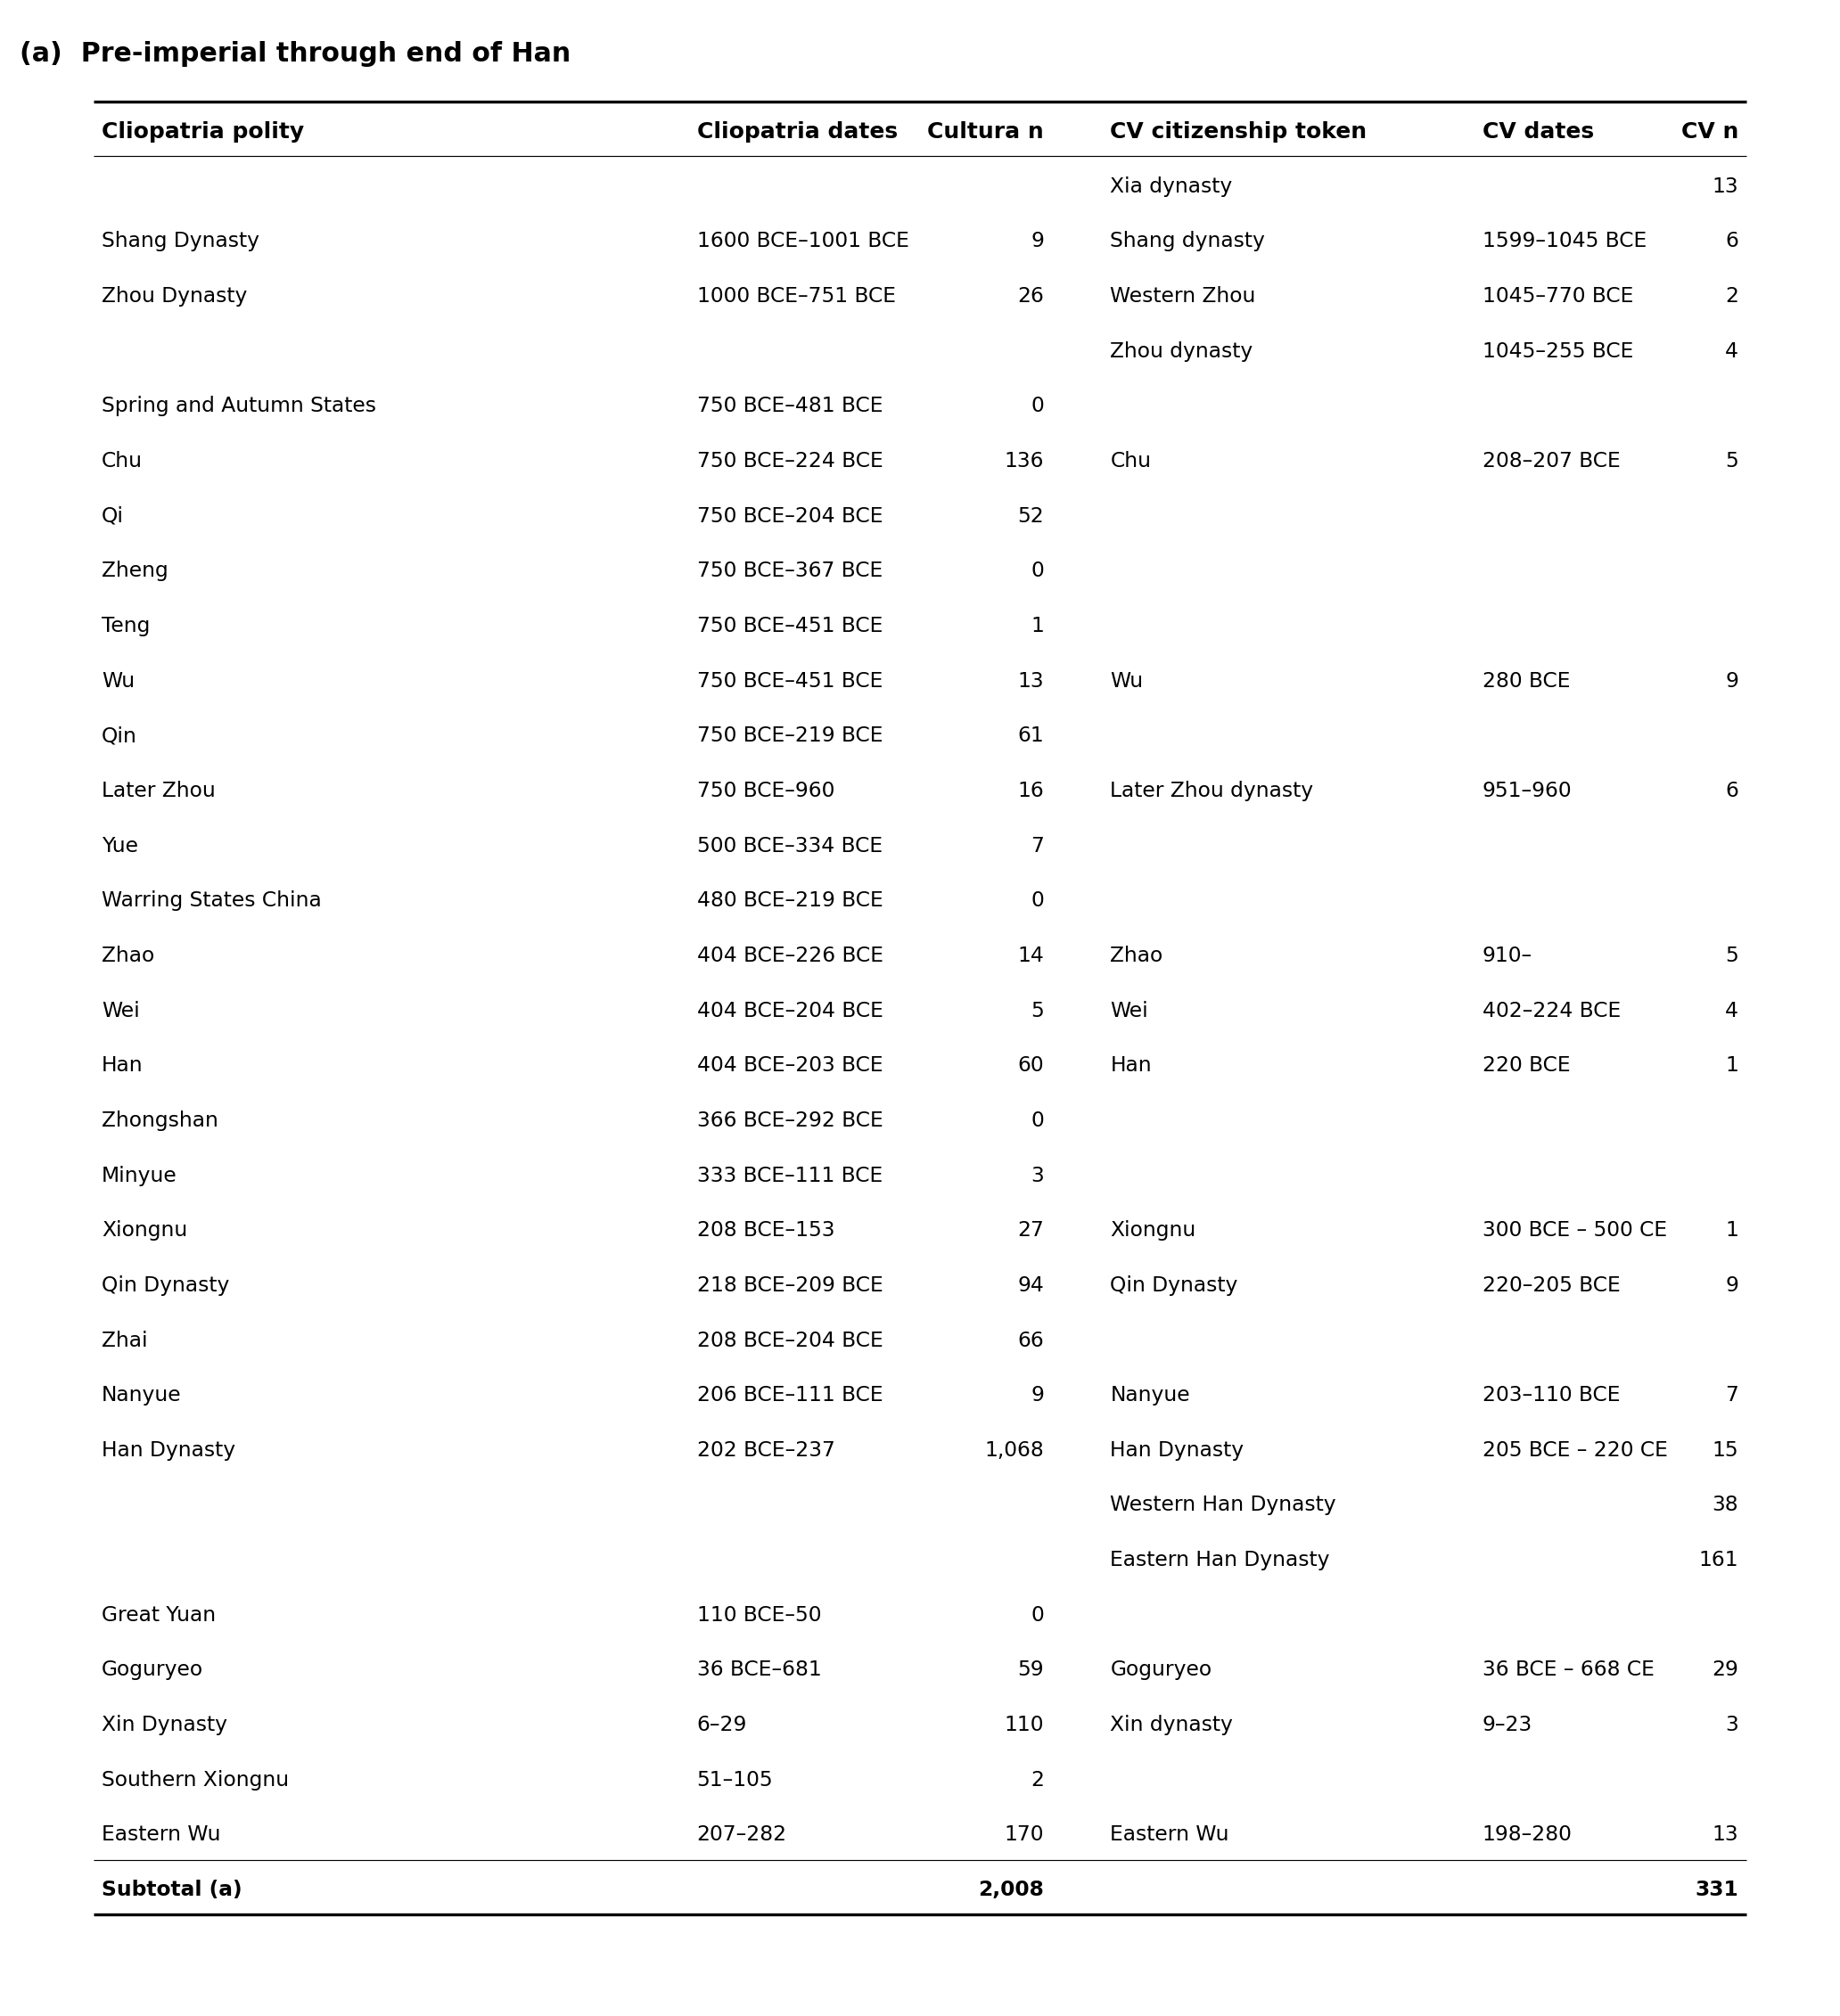

In [8]:
render_pair_table(panel_a, make_subtotal(panel_a, 'Subtotal (a)'), '(a)  Pre-imperial through end of Han')

### Three Kingdoms to Sui

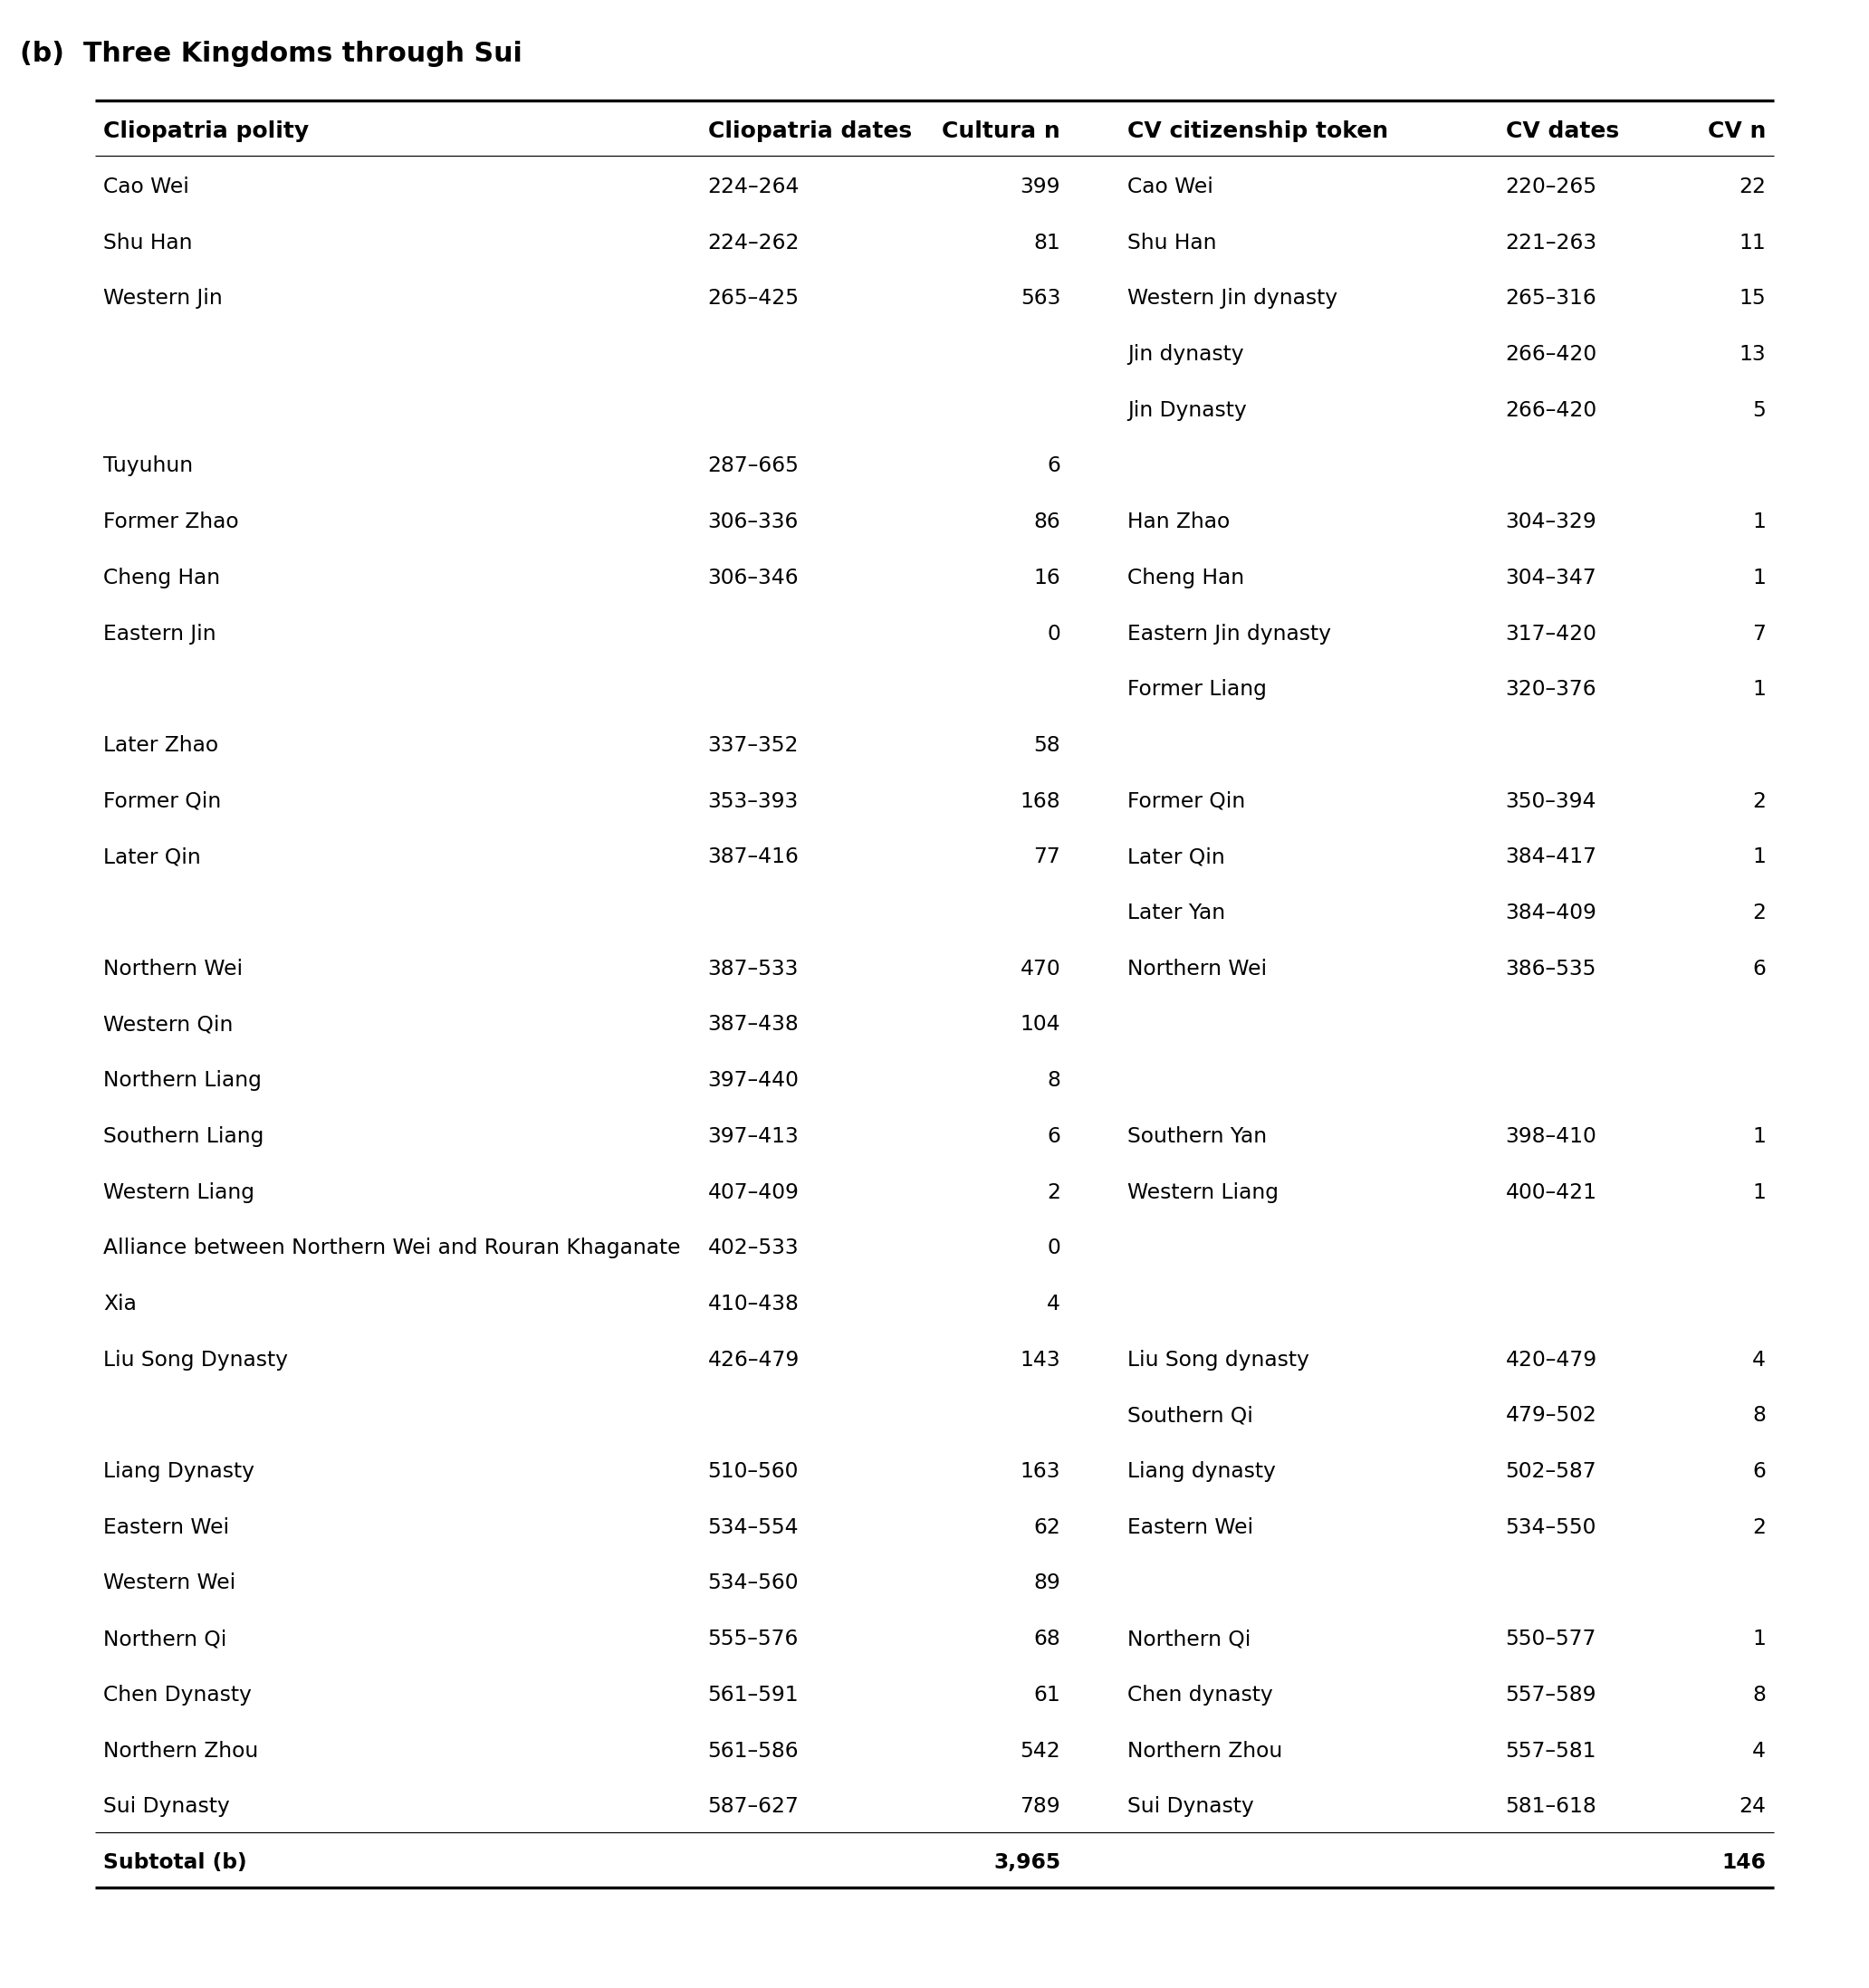

In [9]:
render_pair_table(panel_b, make_subtotal(panel_b, 'Subtotal (b)'), '(b)  Three Kingdoms through Sui')

### Tang to Yuan

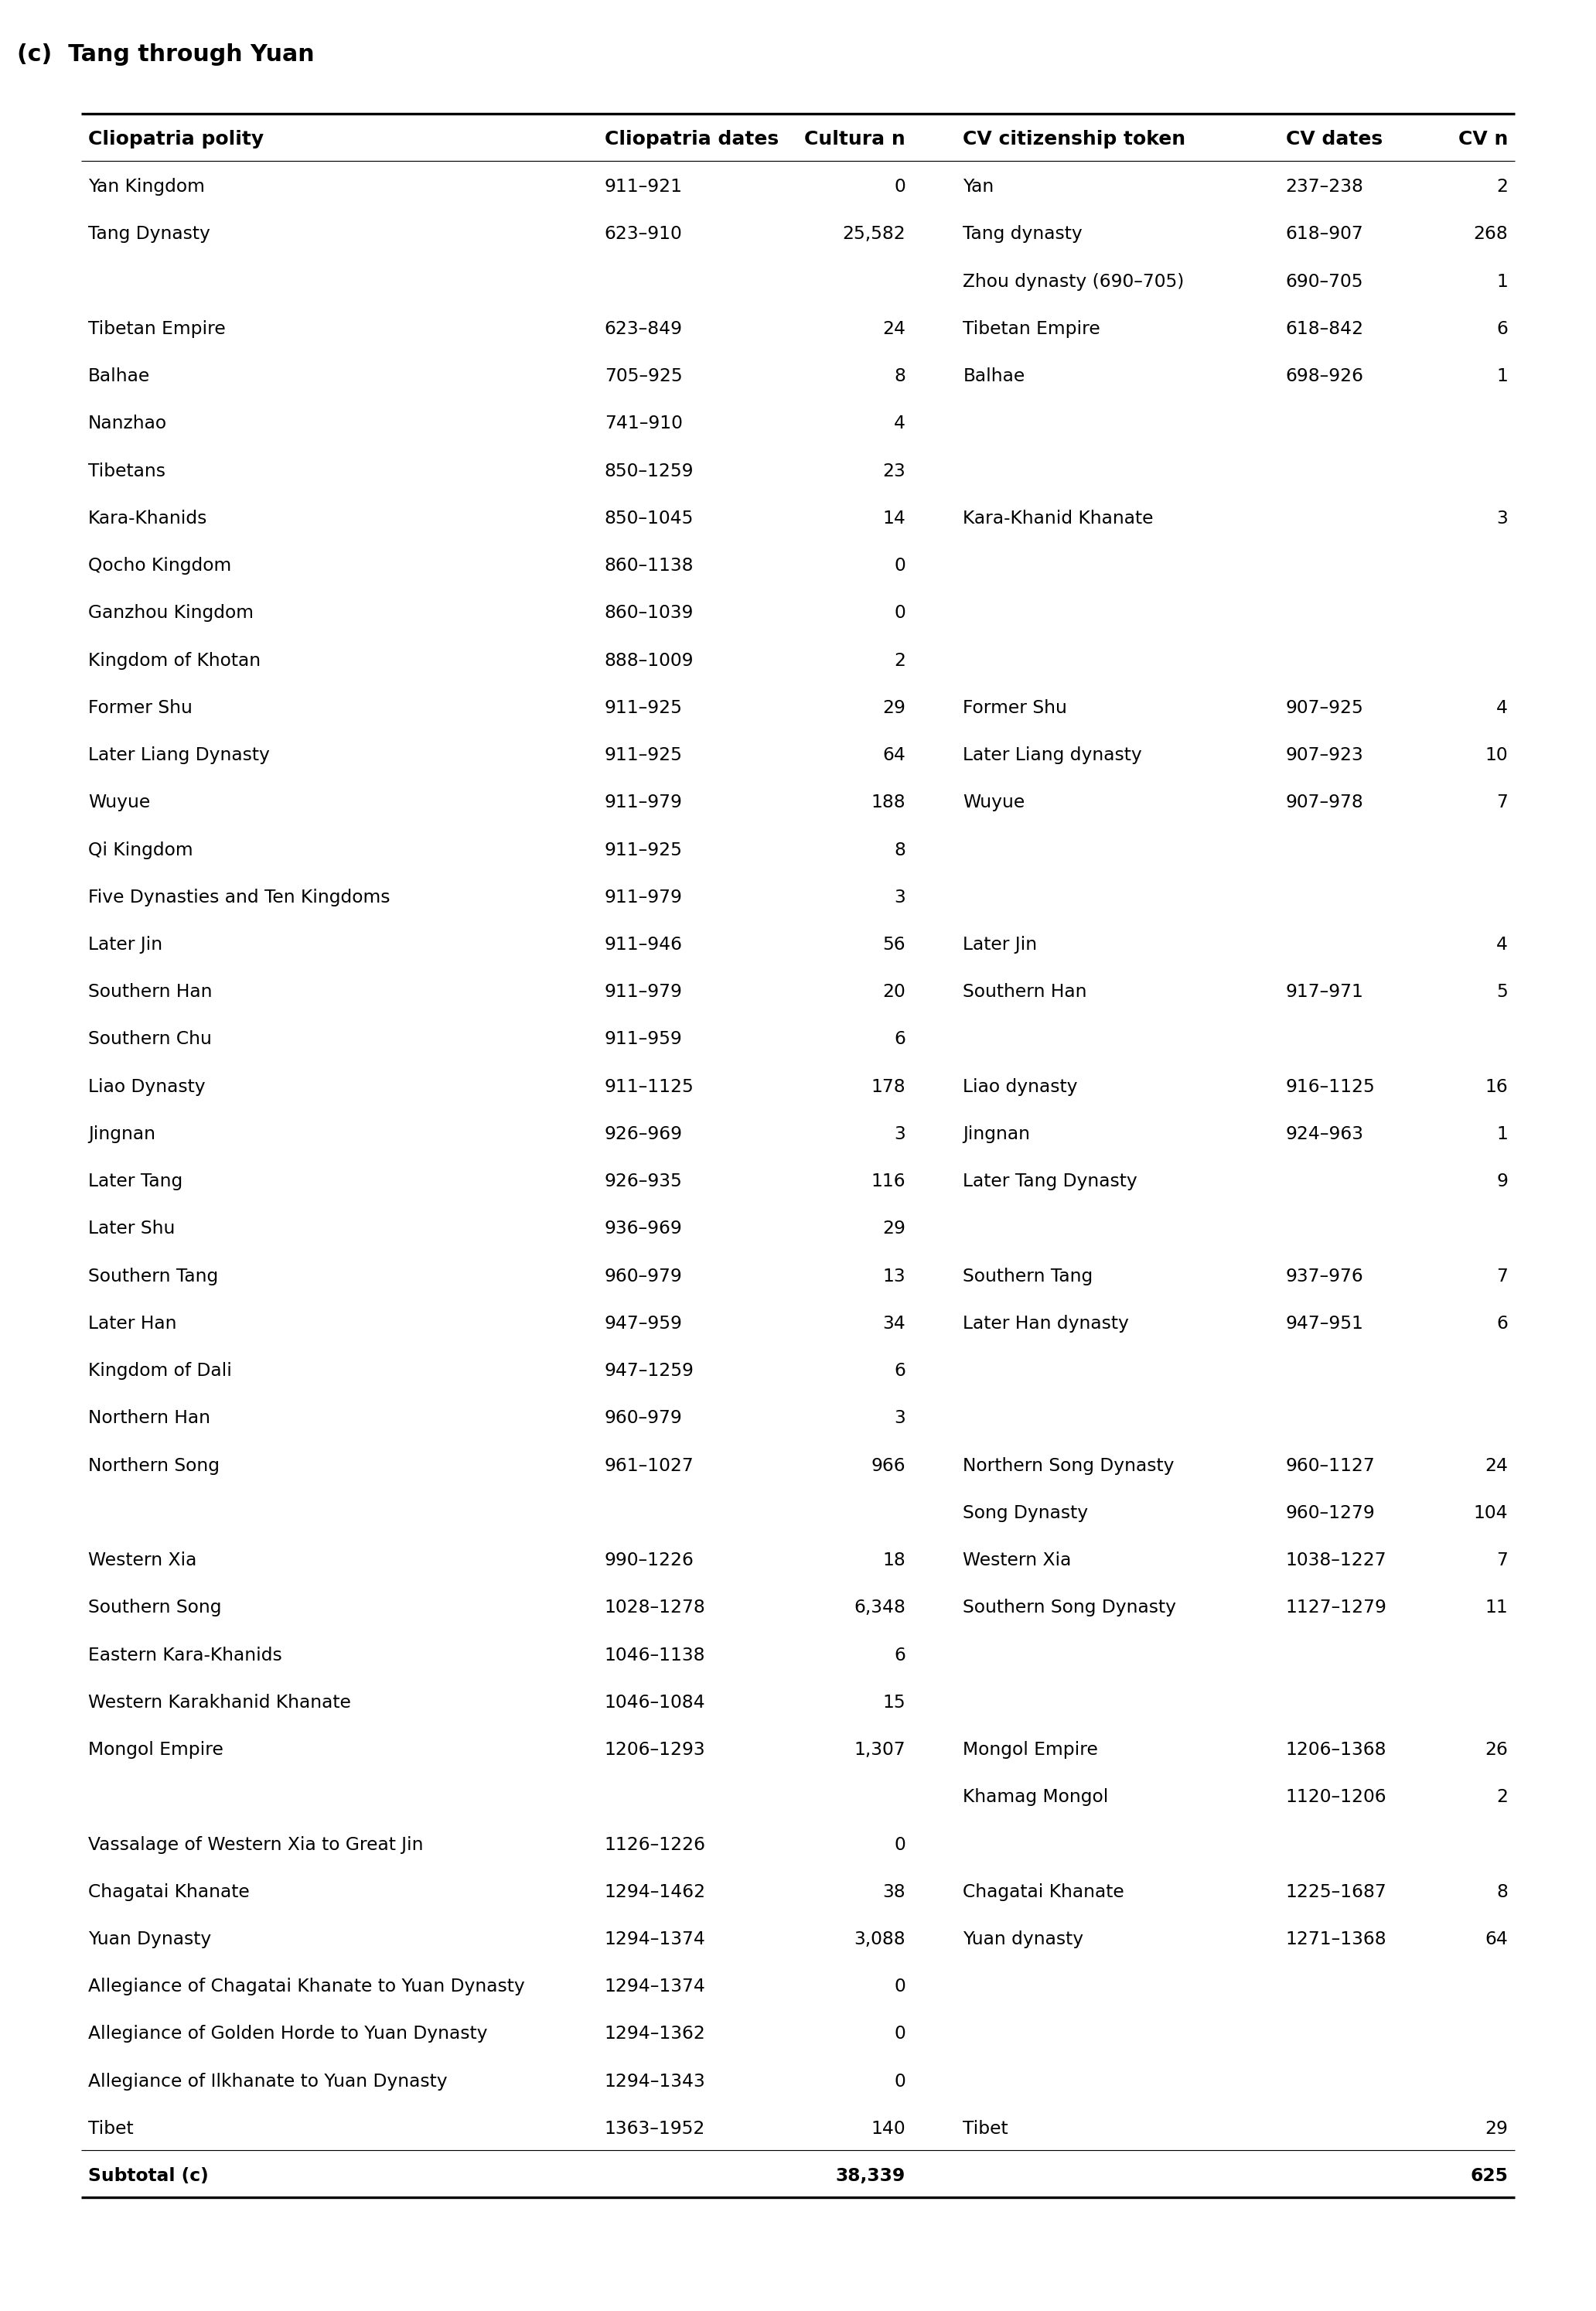

In [10]:
render_pair_table(panel_c, make_subtotal(panel_c, 'Subtotal (c)'), '(c)  Tang through Yuan')

### Ming to PRC

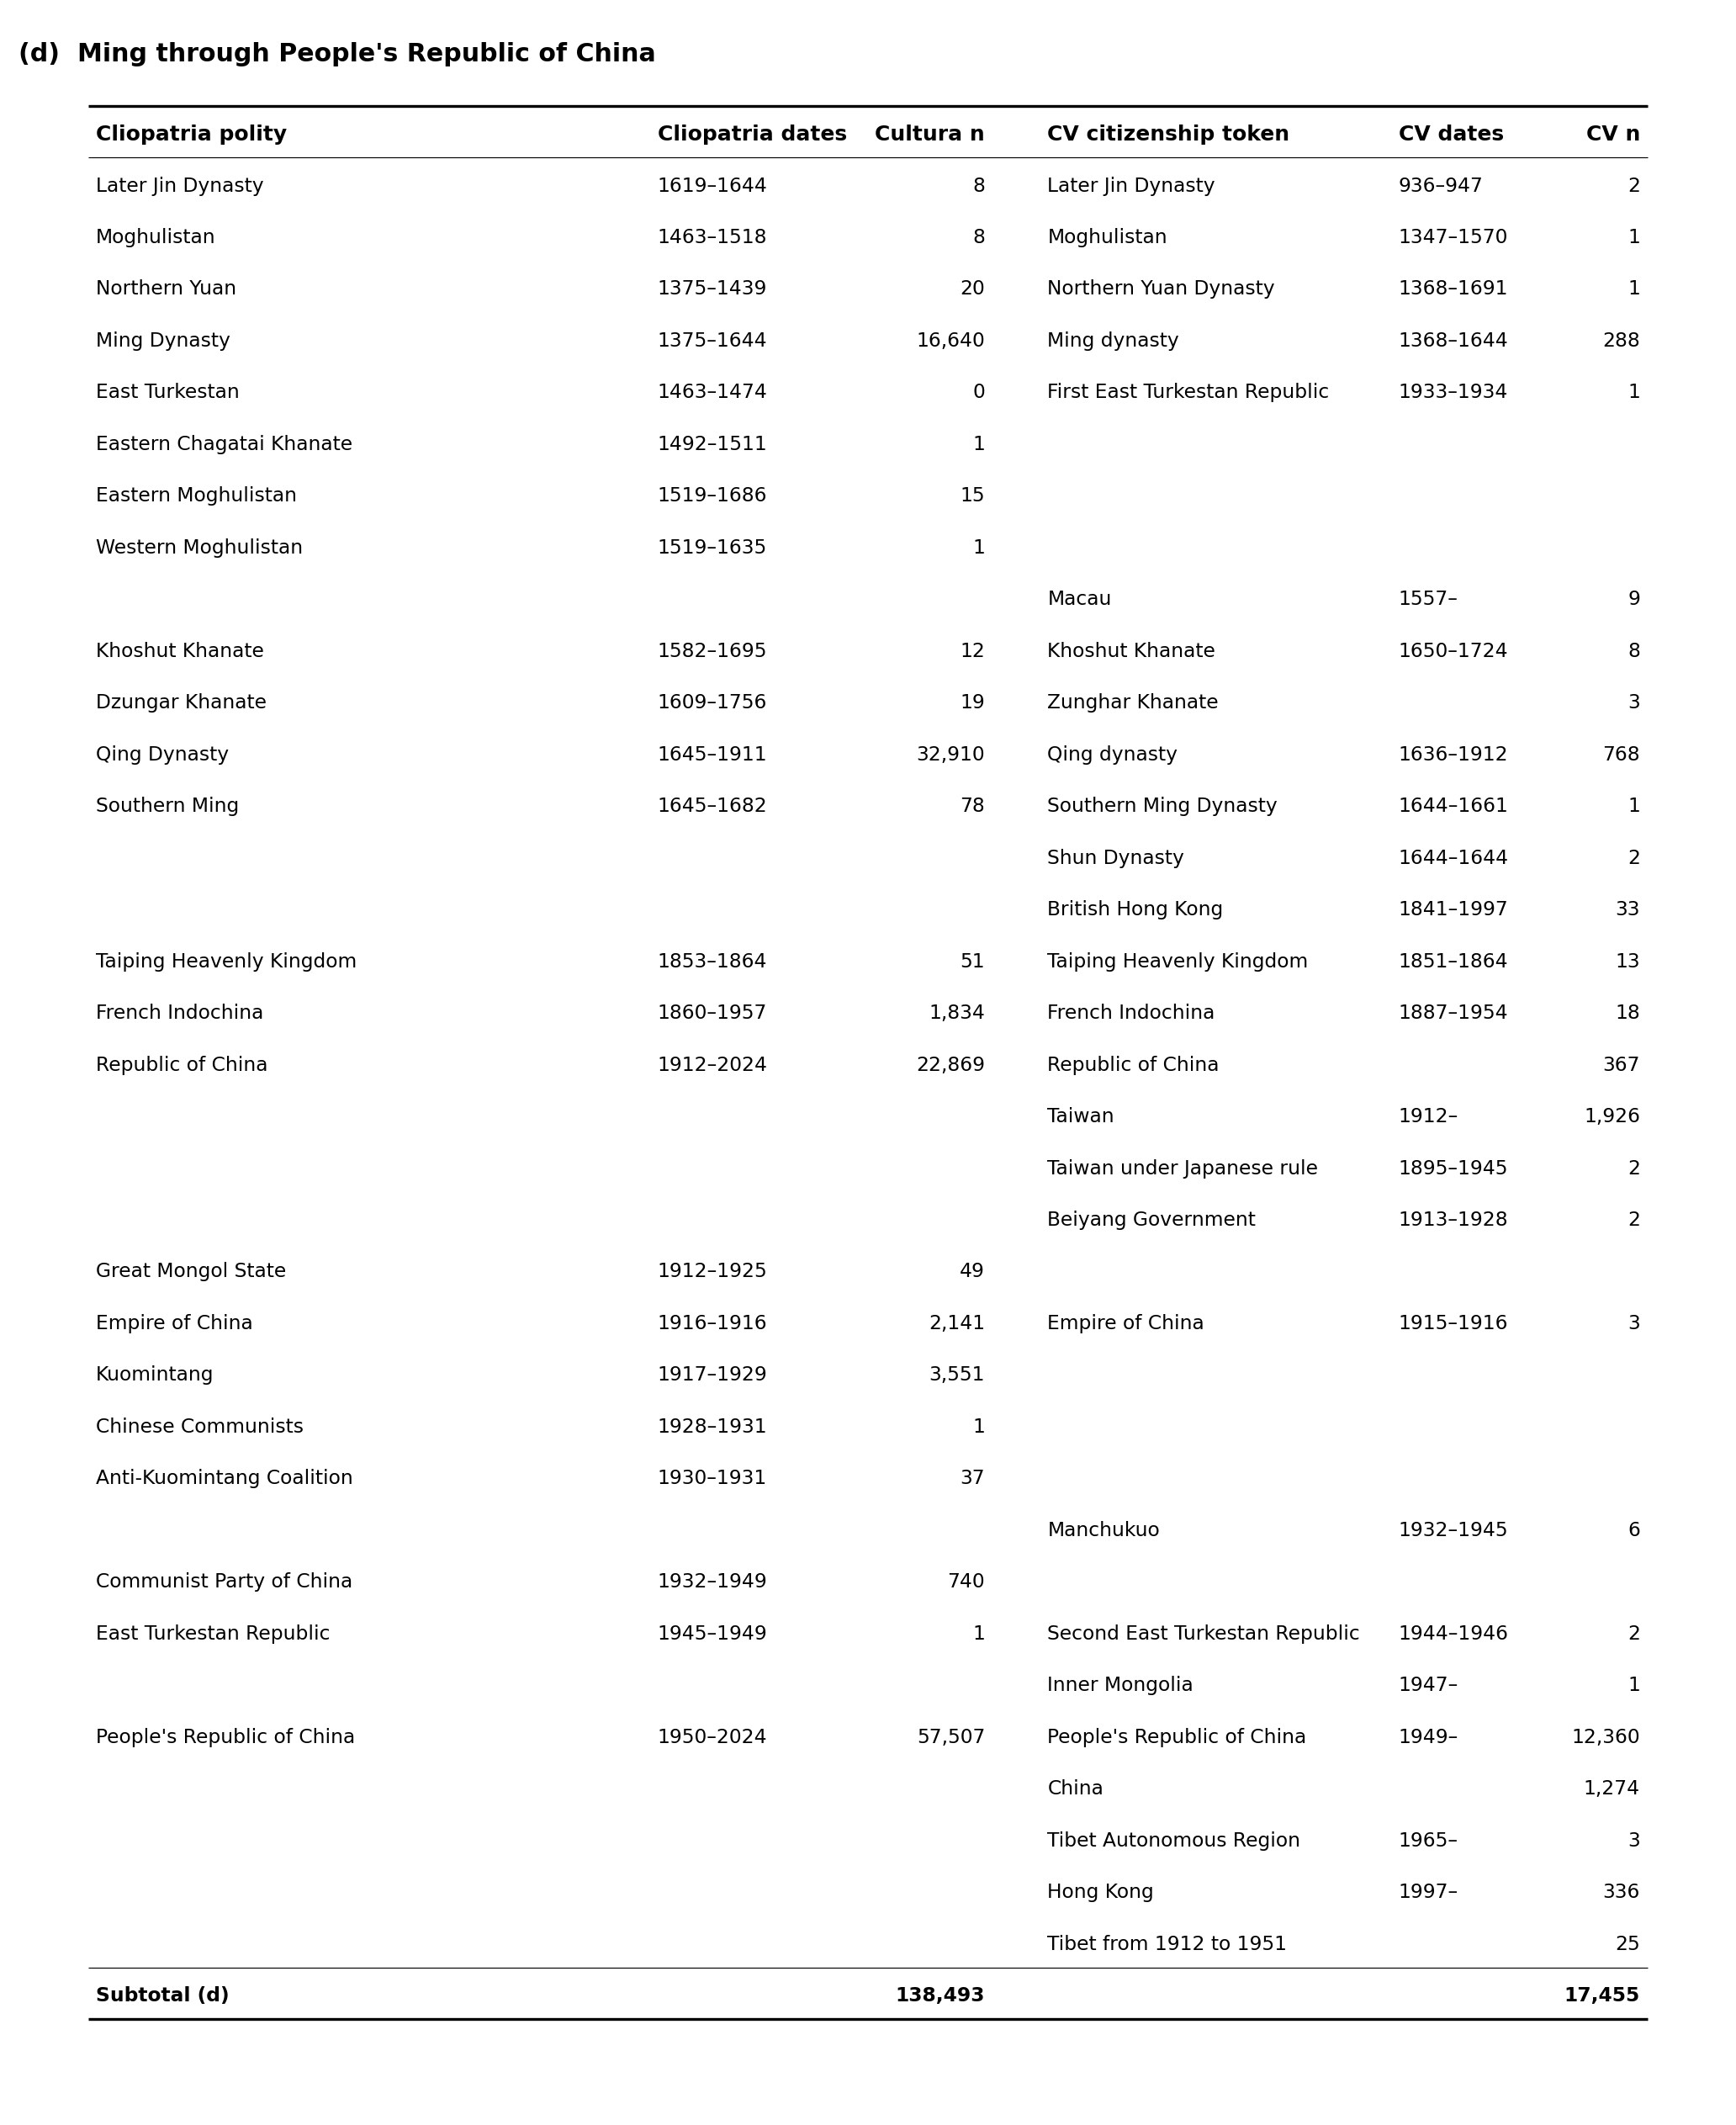

In [11]:
render_pair_table(panel_d, make_subtotal(panel_d, 'Subtotal (d)'), "(d)  Ming through People's Republic of China")

In [12]:
con.close()